# Data Analysis Notebook

This notebook uses data in the `/logs` directory 

In [1]:
# Imports

from glob import glob
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
#Tests where made in Windows, directory separator is set to '\'
base_directory = ".\\logs"
sub_directories = ["V3Sender", "ESP_V3_FullPrototype", "Arduino_LoRa_Sender", "Arduino_FullPrototype"]
idle_directories = ["V3Idle", "Arduino_Idle"]

In [3]:
columns = ["Bus Voltage", "Power", "Current"]
graphs = ["Bus Voltage x Transmission Power", "Power x Transmission Power", "Current x Transmission Power"]
units = ["volt", "miliwatt", "milliampere", "dBi"]

## Heltec WiFi LoRa V3

Energy analysis of the Heltec WiFi LoRa 32 V3 with no extra hardware.

In [ ]:
files_path = "\\".join([base_directory, sub_directories[0]])
files = glob(files_path+"\\*.csv")
idle_file = pd.read_csv("\\".join([base_directory, idle_directories[0], "idle.csv"]))

In [4]:
file = pd.read_csv(files[-1])
for g in columns:
    file[g] = [float(m.split(' ')[0]) for m in file[g]]
for g in columns:
    idle_file[g] = [float(m.split(' ')[0]) for m in idle_file[g]]

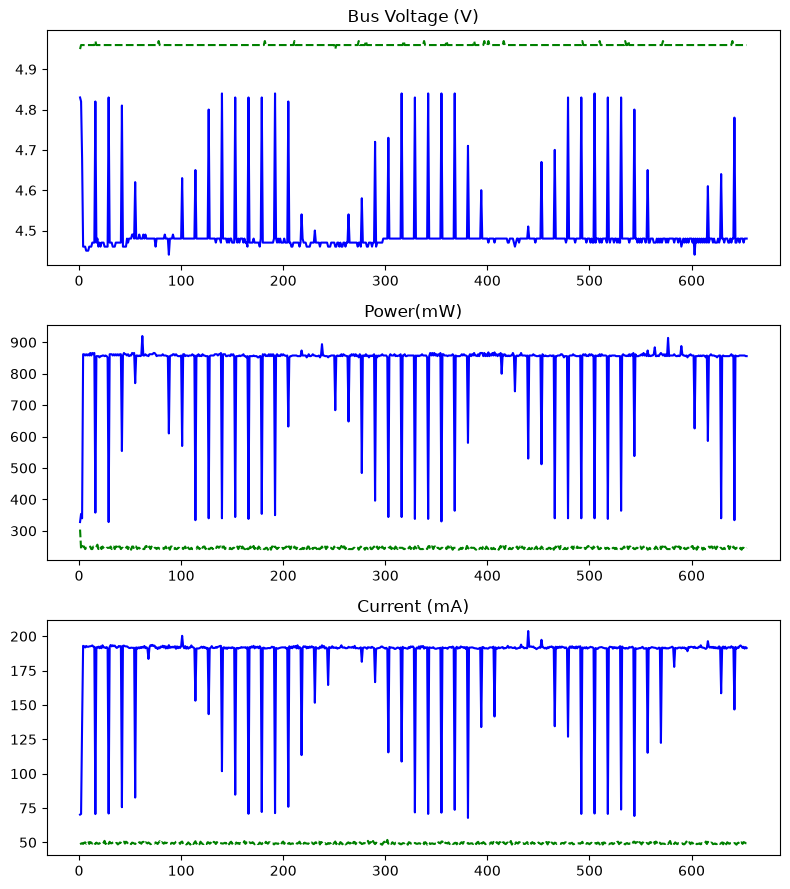

In [5]:

fig, axes = plt.subplots(3, 1, figsize=(8, 9))
for i in range(0,3):
        axes[i].plot(range(1,len(file[columns[i]])+1), file[columns[i]], '-b', label="transmission")
        axes[i].plot(range(1,len(file[columns[i]])+1), idle_file[columns[i]][:len(file[columns[i]])], '--g', label="idle")
        axes[i].set_title(graphs[i])
plt.tight_layout()
plt.show()

In [6]:
file.describe()

,Bus Voltage,Power,Current
count,654.000000,654.000000,654.000000
mean,4.492309,831.532110,186.399541
std,0.071093,108.916288,22.958512
min,4.440000,328.000000,67.800000
25%,4.470000,856.000000,191.300000
50%,4.480000,858.000000,191.700000
75%,4.480000,858.000000,192.100000
max,4.840000,920.000000,203.800000


In [7]:
print(file[columns[2]].max())
print(idle_file[columns[2]].max())

203.8
51.8


## Heltec V3 Full Prototype

Prototype containing a Heltec WiFi LoRa 32 V3, a temperature sensor, a TDS sensor and a PH sensor.

In [ ]:
from glob import glob
import pandas as pd
import matplotlib.pyplot as plt

files_path = "\\".join([base_directory, sub_directories[1]])
files = glob(files_path+"\\*.csv")
idle_file = pd.read_csv("\\".join([base_directory, idle_directories[0], "idle.csv"]))

In [13]:
file = pd.read_csv(files[-1])
for g in columns:
    file[g] = [float(m.split(' ')[0]) for m in file[g]]
for g in columns:
    idle_file[g] = [float(m.split(' ')[0]) for m in idle_file[g]]

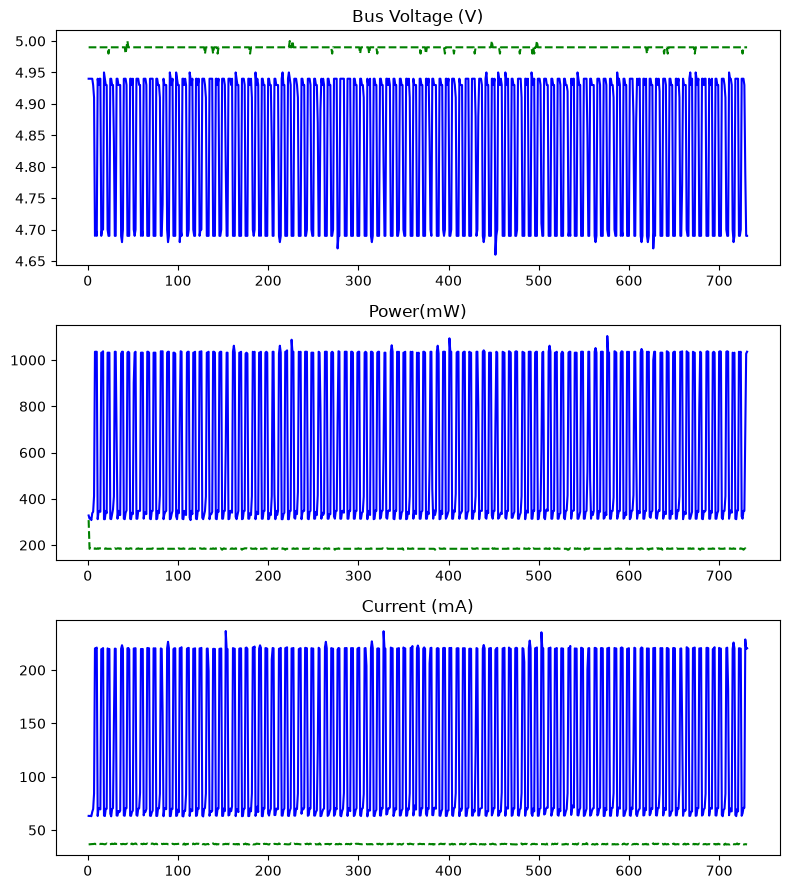

In [14]:
fig, axes = plt.subplots(3, 1, figsize=(8, 9))
for i in range(0,3):
        axes[i].plot(range(1,len(file[columns[i]])+1), file[columns[i]], '-b', label="transmission")
        axes[i].plot(range(1,len(file[columns[i]])+1), idle_file[columns[i]][:len(file[columns[i]])], '--g', label="idle")
        axes[i].set_title(graphs[i])
plt.tight_layout()
plt.show()

## Arduino 

This section uses an Arduino Uno and a LoRa RFM96 Transceiver.


In [ ]:
from glob import glob
import pandas as pd
import matplotlib.pyplot as plt

files_path = "\\".join([base_directory, sub_directories[2]])
files = glob(files_path+"\\*.csv")
idle_file = pd.read_csv("\\".join([base_directory, idle_directories[1], "idle.csv"]))

In [21]:
file = pd.read_csv(files[-1])
for g in columns:
    file[g] = [float(m.split(' ')[0]) for m in file[g]]
for g in columns:
    idle_file[g] = [float(m.split(' ')[0]) for m in idle_file[g]]

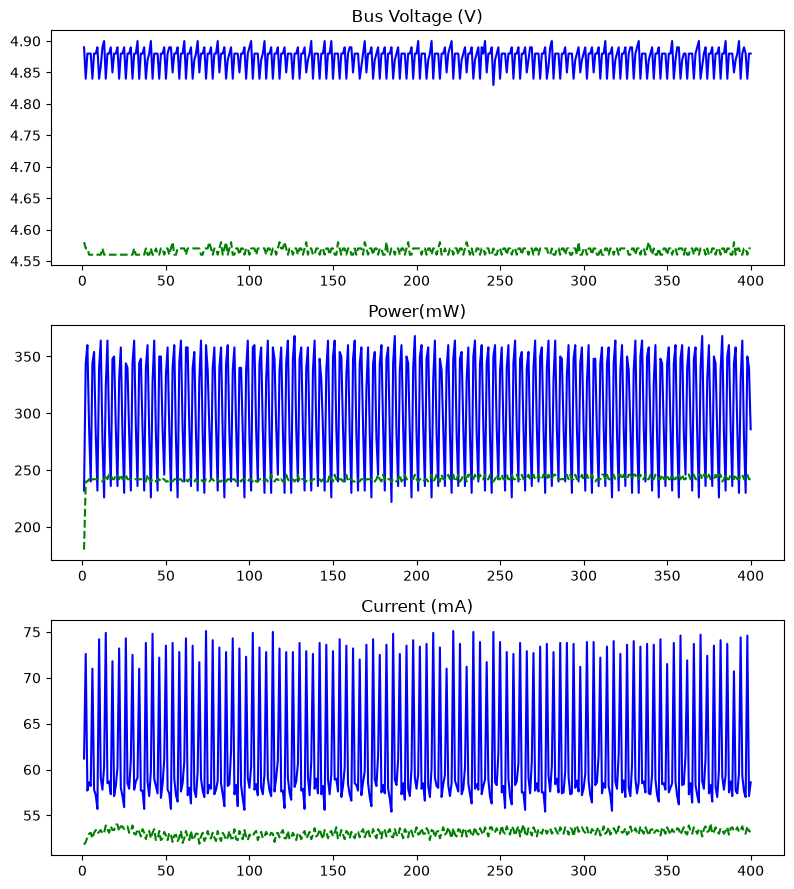

In [22]:
fig, axes = plt.subplots(3, 1, figsize=(8, 9))
for i in range(0,3):
        axes[i].plot(range(1,len(file[columns[i]])+1), file[columns[i]], '-b', label="transmission")
        axes[i].plot(range(1,len(file[columns[i]])+1), idle_file[columns[i]][:len(file[columns[i]])], '--g', label="idle")
        axes[i].set_title(graphs[i])
plt.tight_layout()
plt.show()

## Arduino Full Prototype

Prototype containing a Arduino Uno, a RFM96 LoRa transceiver, a temperature sensor, a TDS sensor and a PH sensor.

In [ ]:
files_path = "\\".join([base_directory, sub_directories[3]])
files = glob(files_path+"\\*.csv")
idle_file = pd.read_csv("\\".join([base_directory, idle_directories[1], "idle.csv"]))

In [24]:
file = pd.read_csv(files[-1])
for g in columns:
    file[g] = [float(m.split(' ')[0]) for m in file[g]]
for g in columns:
    idle_file[g] = [float(m.split(' ')[0]) for m in idle_file[g]]

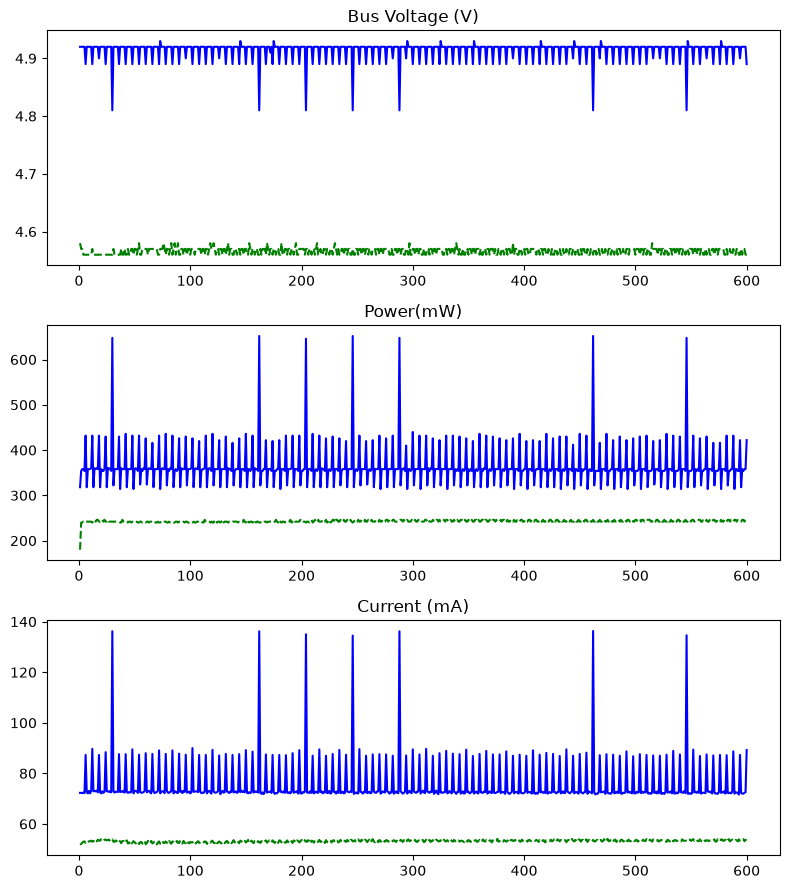

In [26]:
fig, axes = plt.subplots(3, 1, figsize=(8, 9))
for i in range(0,3):
        axes[i].plot(range(1,len(file[columns[i]])+1), file[columns[i]], '-b', label="transmission")
        axes[i].plot(range(1,len(file[columns[i]])+1), idle_file[columns[i]][:len(file[columns[i]])], '--g', label="idle")
        axes[i].set_title(graphs[i])
plt.tight_layout()
plt.show()

## Exploration

Putting all data together for analysis.

In [4]:
ESP_sender_files_path = glob("\\".join([base_directory, sub_directories[0]])+"\\*.csv")
ESP_full_prototype_files_path = glob("\\".join([base_directory, sub_directories[1]])+"\\*.csv")
ESP_idle_file = pd.read_csv("\\".join([base_directory, idle_directories[0], "idle.csv"]))

arduino_sender_files_path = glob("\\".join([base_directory, sub_directories[2]])+"\\*.csv")
arduino_full_prototype_files_path = glob("\\".join([base_directory, sub_directories[3]])+"\\*.csv")
arduino_idle_file = pd.read_csv("\\".join([base_directory, idle_directories[1], "idle.csv"]))

In [5]:
ESP_idle_data = {c : [] for c in columns}
arduino_idle_data = {c : [] for c in columns}
ESP_sender_data = {c : [] for c in columns}
ESP_full_prototype_data = {c : [] for c in columns}
arduino_sender_data = {c : [] for c in columns}
arduino_full_prototype_data = {c : [] for c in columns}

for c in columns:
    ESP_idle_file[c] = [float(m.split(' ')[0]) for m in ESP_idle_file[c]]
    ESP_idle_data[c] = [ESP_idle_file[c].min(), ESP_idle_file[c].mean(), ESP_idle_file[c].max()]

for c in columns:
    arduino_idle_file[c] = [float(m.split(' ')[0]) for m in arduino_idle_file[c]]
    arduino_idle_data[c] = [arduino_idle_file[c].min(), arduino_idle_file[c].mean(), arduino_idle_file[c].max()]

for file in ESP_sender_files_path:
    f = pd.read_csv(file)
    for c in columns:
        f[c] = [float(m.split(' ')[0]) for m in f[c]]
        ESP_sender_data[c].append([f[c].min(), f[c].mean(), f[c].max()])

for file in ESP_full_prototype_files_path:
    f = pd.read_csv(file)
    for c in columns:
        f[c] = [float(m.split(' ')[0]) for m in f[c]]
        ESP_full_prototype_data[c].append([f[c].min(), f[c].mean(), f[c].max()])

for file in arduino_sender_files_path:
    f = pd.read_csv(file)
    for c in columns:
        f[c] = [float(m.split(' ')[0]) for m in f[c]]
        arduino_sender_data[c].append([f[c].min(), f[c].mean(), f[c].max()])

for file in arduino_full_prototype_files_path:
    f = pd.read_csv(file)
    for c in columns:
        f[c] = [float(m.split(' ')[0]) for m in f[c]]
        arduino_full_prototype_data[c].append([f[c].min(), f[c].mean(), f[c].max()])

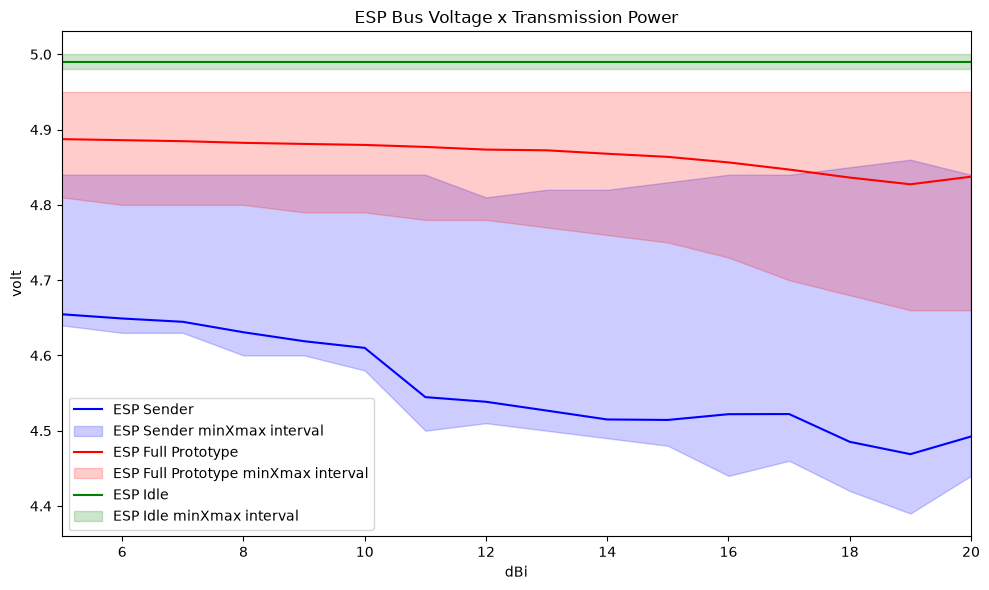

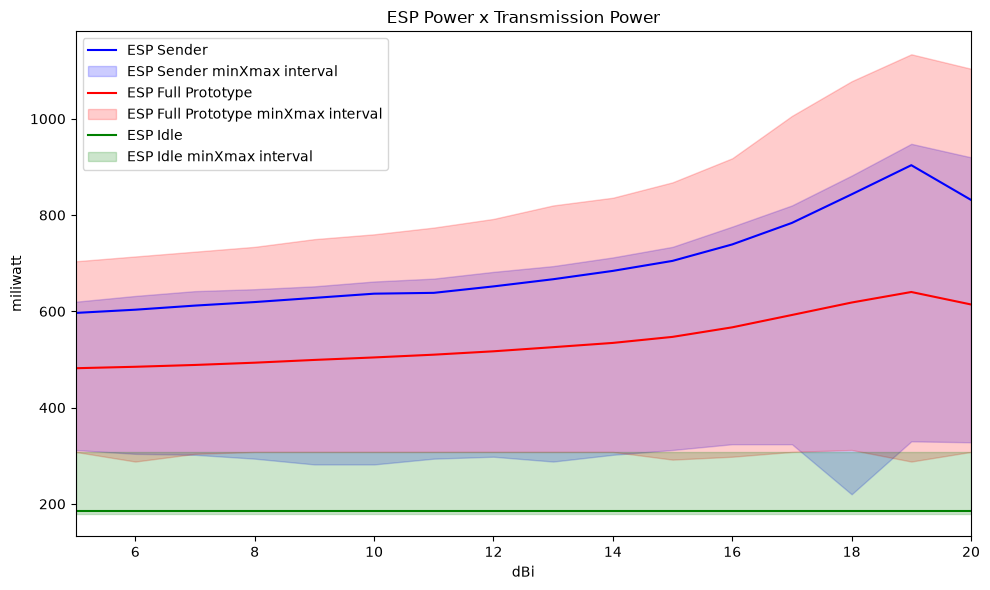

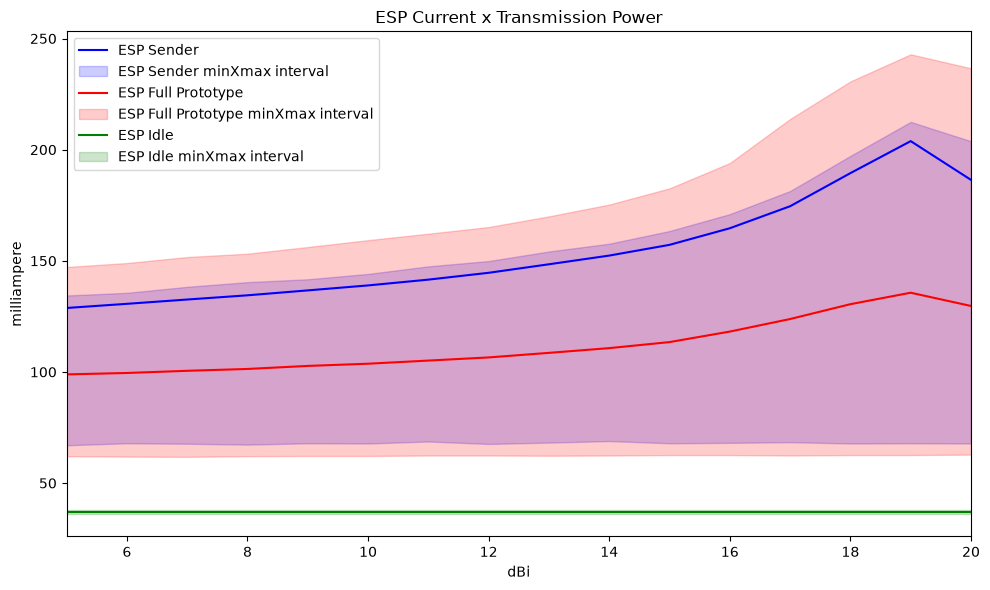

In [6]:
# Graphs comparing ESP prototypes
for i in range(len(columns)):
    plt.figure(figsize=(10, 6))
    c = columns[i]
    x_range = range(5,21)
    plt.plot(x_range, [e[1] for e in ESP_sender_data[c]], color="blue", label="ESP Sender")
    plt.fill_between(x_range, [e[0] for e in ESP_sender_data[c]], [e[2] for e in ESP_sender_data[c]], color="blue", alpha=0.2, label="ESP Sender minXmax interval")
    
    plt.plot(x_range, [e[1] for e in ESP_full_prototype_data[c]], color="red", label="ESP Full Prototype")
    plt.fill_between(x_range, [e[0] for e in ESP_full_prototype_data[c]], [e[2] for e in ESP_full_prototype_data[c]], color="red", alpha=0.2, label="ESP Full Prototype minXmax interval")

    plt.plot(x_range, [ESP_idle_data[c][1] for _ in x_range], color="green", label="ESP Idle")
    plt.fill_between(x_range, [ESP_idle_data[c][0] for _ in x_range], [ESP_idle_data[c][2] for _ in x_range], color="green", alpha=0.2, label="ESP Idle minXmax interval")

    plt.title("ESP " + graphs[i])
    plt.legend()
    plt.xlabel(units[-1])
    plt.ylabel(units[i])
    plt.xlim(5,20)
    plt.tight_layout()
    plt.show()


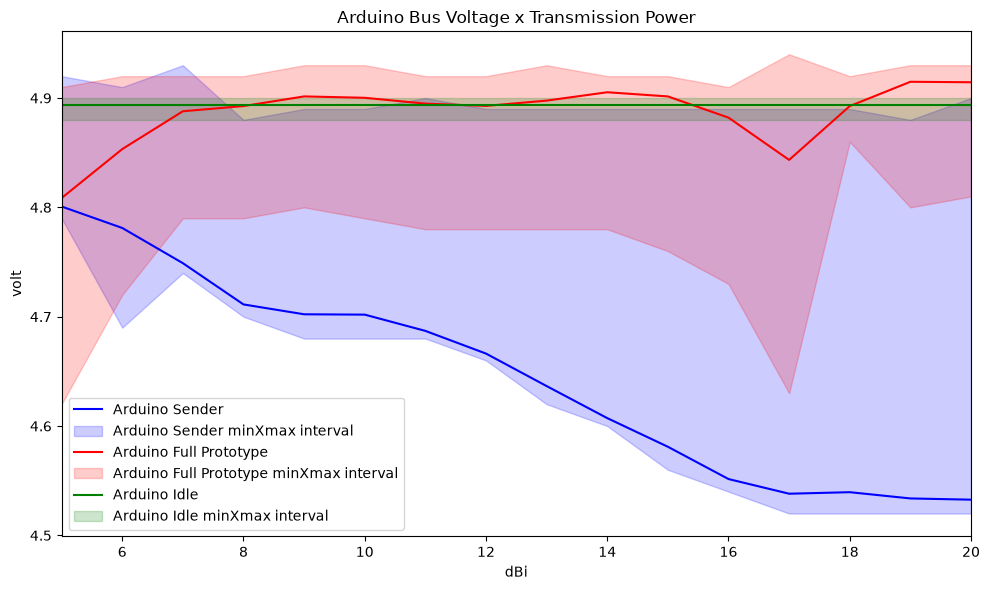

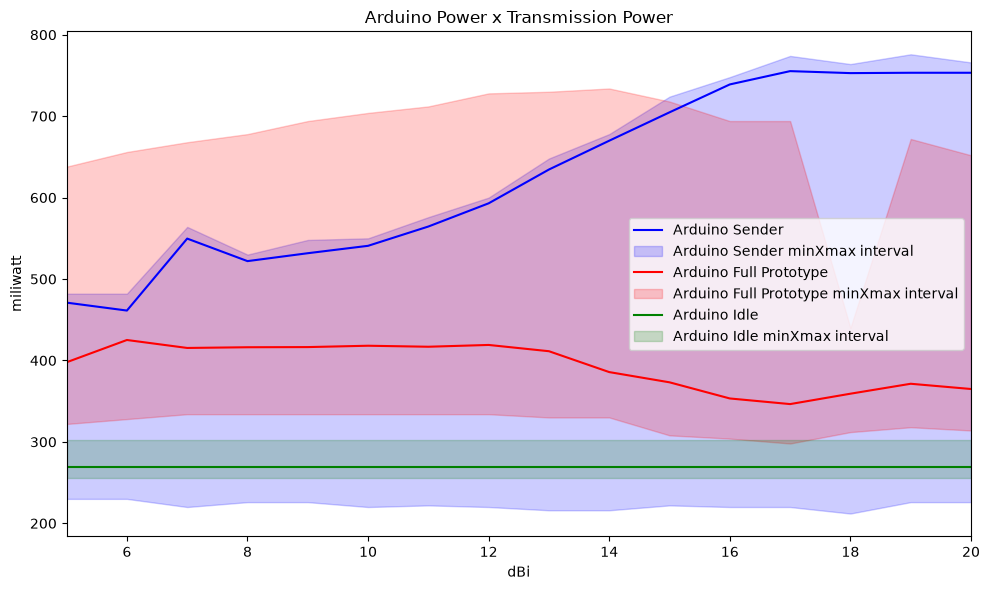

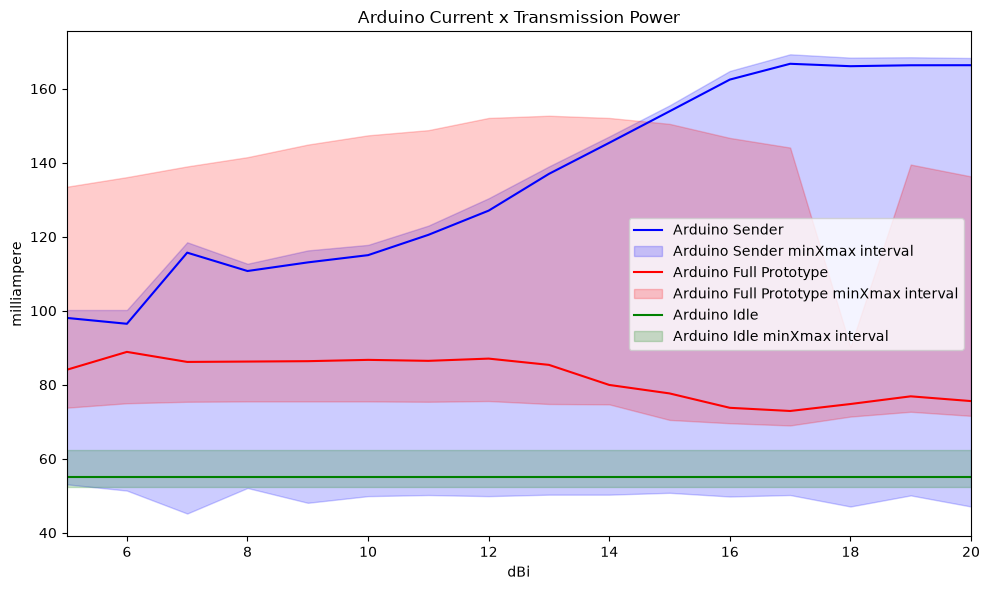

In [7]:
# Graphs comparing Arduino prototypes
for i in range(len(columns)):
    plt.figure(figsize=(10, 6))
    c = columns[i]
    x_range = range(5,21)
    plt.plot(x_range, [e[1] for e in arduino_sender_data[c]], color="blue", label="Arduino Sender")
    plt.fill_between(x_range, [e[0] for e in arduino_sender_data[c]], [e[2] for e in arduino_sender_data[c]], color="blue", alpha=0.2, label="Arduino Sender minXmax interval")
    
    plt.plot(x_range, [e[1] for e in arduino_full_prototype_data[c]], color="red", label="Arduino Full Prototype")
    plt.fill_between(x_range, [e[0] for e in arduino_full_prototype_data[c]], [e[2] for e in arduino_full_prototype_data[c]], color="red", alpha=0.2, label="Arduino Full Prototype minXmax interval")

    plt.plot(x_range, [arduino_idle_data[c][1] for _ in x_range], color="green", label="Arduino Idle")
    plt.fill_between(x_range, [arduino_idle_data[c][0] for _ in x_range], [arduino_idle_data[c][2] for _ in x_range], color="green", alpha=0.2, label="Arduino Idle minXmax interval")

    plt.title("Arduino " + graphs[i])
    plt.legend()
    plt.xlabel(units[-1])
    plt.ylabel(units[i])
    plt.xlim(5,20)
    plt.tight_layout()
    plt.show()


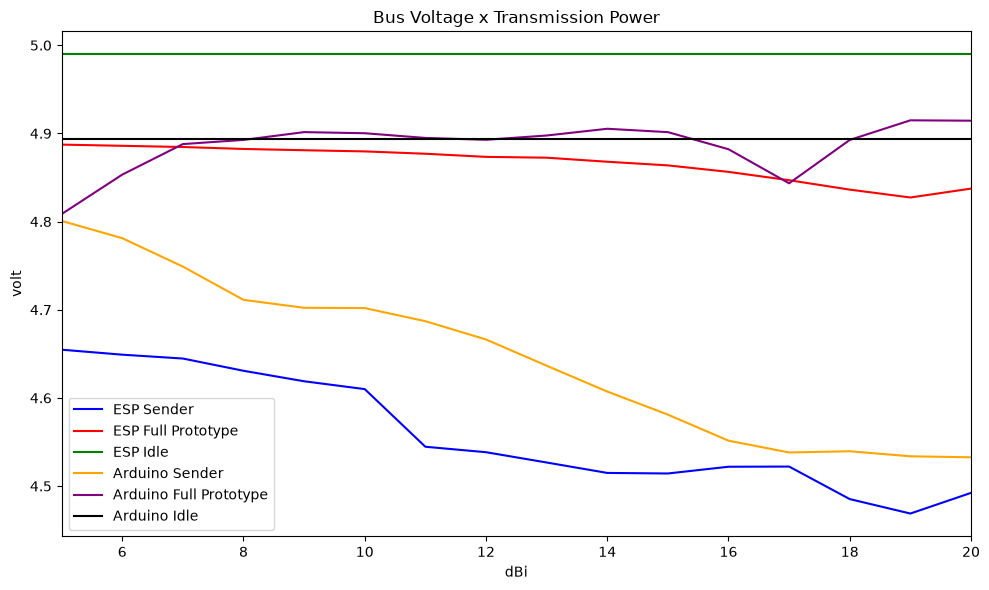

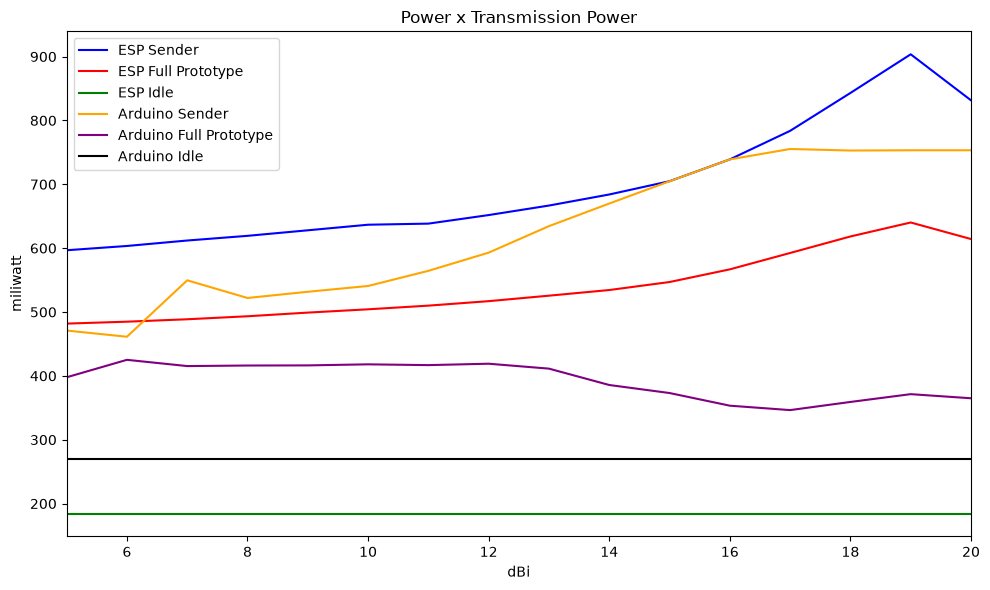

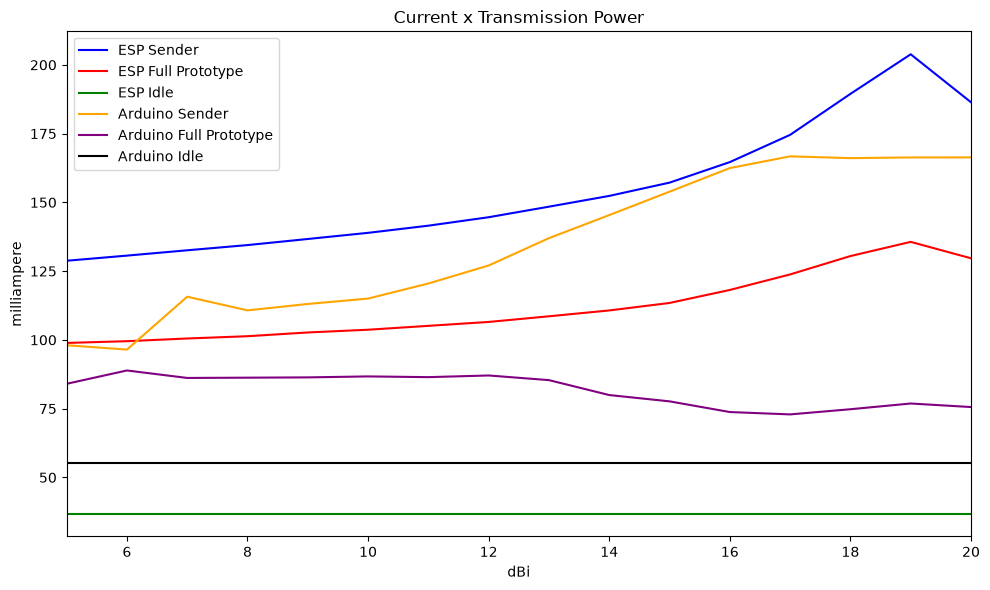

In [8]:
# Graphs with all means
for i in range(len(columns)):
    plt.figure(figsize=(10, 6))
    c = columns[i]
    x_range = range(5,21)

    plt.plot(x_range, [e[1] for e in ESP_sender_data[c]], color="blue", label="ESP Sender")
    
    plt.plot(x_range, [e[1] for e in ESP_full_prototype_data[c]], color="red", label="ESP Full Prototype")
    
    plt.plot(x_range, [ESP_idle_data[c][1] for _ in x_range], color="green", label="ESP Idle")

    plt.plot(x_range, [e[1] for e in arduino_sender_data[c]], color="orange", label="Arduino Sender")
    
    plt.plot(x_range, [e[1] for e in arduino_full_prototype_data[c]], color="purple", label="Arduino Full Prototype")
    
    plt.plot(x_range, [arduino_idle_data[c][1] for _ in x_range], color="black", label="Arduino Idle")
    
    plt.title(graphs[i])
    plt.legend()
    plt.xlabel(units[-1])
    plt.ylabel(units[i])
    plt.xlim(5,20)
    plt.tight_layout()
    plt.show()
